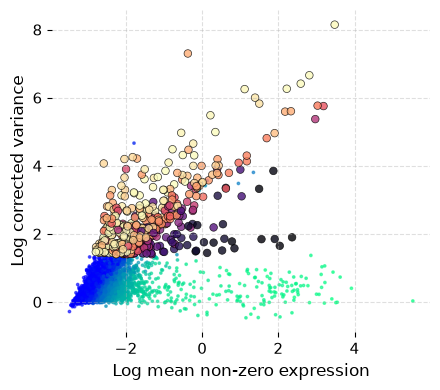

In [1]:
import scarf
import scarf.plotting as splt

scarf.set_verbosity('WARNING')

scarf.fetch_dataset(
    'tenx_5K_pbmc_rnaseq',
    save_path='scarf_datasets',
    as_zarr=True,
)
ds = scarf.DataStore(
    'scarf_datasets/tenx_5K_pbmc_rnaseq/data.zarr',
    nthreads=4,
    min_features_per_cell=10,
)
ds.filter_cells(
    attrs=['RNA_nCounts', 'RNA_nFeatures', 'RNA_percentMito'],
    highs=[15000, 4000, 15],
    lows=[1000, 500, 0],
    reset_previous=True,
)
ds.mark_hvgs(min_cells=20, top_n=500)
ds.make_graph(feat_key='hvgs', k=11, dims=15, n_centroids=100)
ds.run_umap(n_epochs=150, spread=5, min_dist=1, parallel=True)
ds.run_leiden_clustering(resolution=0.5)

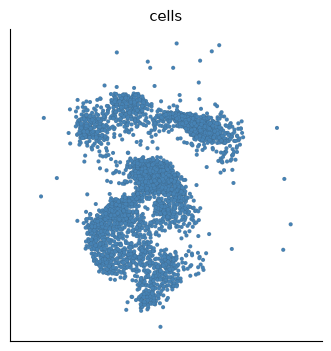

In [2]:
ds.run_umap(
    n_epochs=150,
    spread=5,
    min_dist=1,
    parallel=True,
    use_density_map=True,
    label='densMAP',
)
splt.embedding(ds, layout_key='RNA_densMAP').show();

parallel=True is not supported by the sgtsnepi Python backend; running single-threaded



Number of vertices: 3940


Embedding dimensions: 2


Rescaling parameter λ: 1


Early exag. multiplier α: 10


...

Iteration 400: error is 2.78369 (50 iterations in 0.088285 seconds)


Iteration 450: error is 2.76323 (50 iterations in 0.088075 seconds)


Iteration 499: error is 2.75948 (50 iterations in 0.084352 seconds)


 --- Time spent in each module --- 



 Attractive forces: 0.131766 sec [21.2617%] |  Repulsive forces: 0.487968 sec [78.7383%]


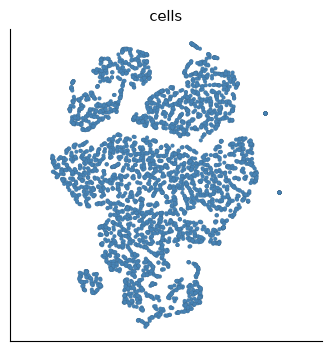

In [3]:
ds.run_tsne(
    alpha=10,
    box_h=1,
    early_iter=250,
    max_iter=500,
    parallel=True,
)
splt.embedding(ds, layout_key='RNA_tSNE').show();

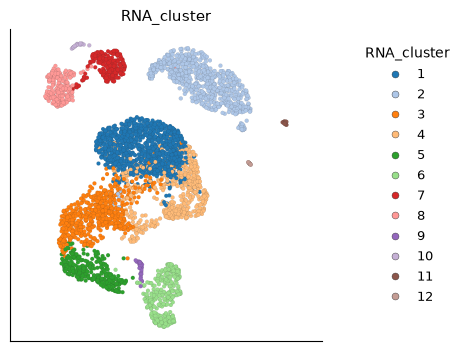

In [4]:
n_clusters = int(
    ds.cells.to_pandas_dataframe(
        columns=['RNA_leiden_cluster'], key='I'
    )['RNA_leiden_cluster'].nunique()
)
ds.run_clustering(n_clusters=n_clusters)
splt.embedding(
    ds,
    layout_key='RNA_UMAP',
    color_by='RNA_cluster',
).show();

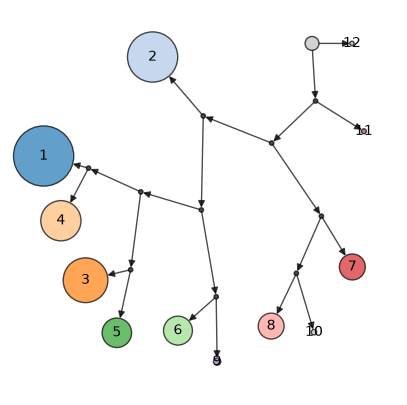

In [5]:
splt.cluster_tree(ds, cluster_key='RNA_cluster', width=1)